# Email Spam / Ham Classifier

## Name: Victor Chinekezi
## Department: Computer Science
## Reg No: 20231394432
## Course: CSC 309 (Artificial Intelligence)
## Date: 13 April 2026

**Dataset**: SpamAssassin Public Corpus  
**Model**: TF-IDF + Logistic Regression (also trains Naive Bayes for comparison)  
**Output**: `model.pkl` and `vectorizer.pkl` — loaded by the Flask API

## 1. Install dependencies

### pip install scikit-learn pandas numpy matplotlib seaborn requests tqdm joblib

## 2. Download & extract the SpamAssassin dataset

In [1]:
import os, tarfile, email, requests
from pathlib import Path
from tqdm import tqdm

DATA_DIR = Path('spamassassin')
DATA_DIR.mkdir(exist_ok=True)

TARBALLS = [
    ('ham',  'https://spamassassin.apache.org/old/publiccorpus/20030228_easy_ham.tar.bz2'),
    ('ham',  'https://spamassassin.apache.org/old/publiccorpus/20030228_easy_ham_2.tar.bz2'),
    ('spam', 'https://spamassassin.apache.org/old/publiccorpus/20030228_spam.tar.bz2'),
    ('spam', 'https://spamassassin.apache.org/old/publiccorpus/20050311_spam_2.tar.bz2'),
]

def download(url, dest):
    r = requests.get(url, stream=True, timeout=60)
    r.raise_for_status()
    total = int(r.headers.get('content-length', 0))
    with open(dest, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True, desc=dest.name) as bar:
        for chunk in r.iter_content(8192):
            f.write(chunk)
            bar.update(len(chunk))

for label, url in TARBALLS:
    fname = DATA_DIR / Path(url).name
    if not fname.exists():
        print(f'Downloading {fname.name}...')
        download(url, fname)
    dest = DATA_DIR / label
    dest.mkdir(exist_ok=True)
    print(f'Extracting {fname.name} → {dest}/')
    with tarfile.open(fname, 'r:bz2') as tf:
        tf.extractall(dest)

print('Done!')

20030228_easy_ham.tar.bz2: 100%|██████████████████████████████████████████████████████████████| 1.61M/1.61M [00:01<00:00, 929kB/s]


Extracting 20030228_easy_ham.tar.bz2 → spamassassin/ham/


20030228_easy_ham_2.tar.bz2: 100%|████████████████████████████████████████████████████████████| 1.08M/1.08M [00:01<00:00, 870kB/s]


Extracting 20030228_easy_ham_2.tar.bz2 → spamassassin/ham/


20030228_spam.tar.bz2: 100%|██████████████████████████████████████████████████████████████████| 1.18M/1.18M [00:01<00:00, 921kB/s]


Extracting 20030228_spam.tar.bz2 → spamassassin/spam/


20050311_spam_2.tar.bz2: 100%|████████████████████████████████████████████████████████████████| 2.06M/2.06M [00:02<00:00, 949kB/s]


Extracting 20050311_spam_2.tar.bz2 → spamassassin/spam/
Done!


## 3. Parse emails into a DataFrame

In [2]:
import pandas as pd

def parse_email(path):
    """Extract plain-text body from a raw email file."""
    try:
        raw = path.read_bytes()
        msg = email.message_from_bytes(raw)
        parts = []
        if msg.is_multipart():
            for part in msg.walk():
                if part.get_content_type() == 'text/plain':
                    try:
                        parts.append(part.get_payload(decode=True).decode('utf-8', errors='ignore'))
                    except Exception:
                        pass
        else:
            try:
                parts.append(msg.get_payload(decode=True).decode('utf-8', errors='ignore'))
            except Exception:
                parts.append(str(msg.get_payload()))
        subject = msg.get('Subject', '')
        body = ' '.join(parts)
        return f'{subject} {body}'.strip()
    except Exception:
        return ''

records = []
for label in ('ham', 'spam'):
    folder = DATA_DIR / label
    files = [f for f in folder.rglob('*') if f.is_file() and not f.name.endswith('.tar.bz2')]
    print(f'{label}: {len(files)} files')
    for f in tqdm(files, desc=label):
        text = parse_email(f)
        if len(text) > 20:
            records.append({'text': text, 'label': label})

df = pd.DataFrame(records)
df['label_num'] = (df['label'] == 'spam').astype(int)
print(f'\nTotal: {len(df)} emails')
df['label'].value_counts()

ham: 3902 files


ham: 100%|█████████████████████████████████████████████████████████████████████████████████| 3902/3902 [00:00<00:00, 10289.00it/s]


spam: 1898 files


spam: 100%|█████████████████████████████████████████████████████████████████████████████████| 1898/1898 [00:00<00:00, 7914.39it/s]


Total: 5790 emails


label
ham     3902
spam    1888
Name: count, dtype: int64

## 4. Explore the data

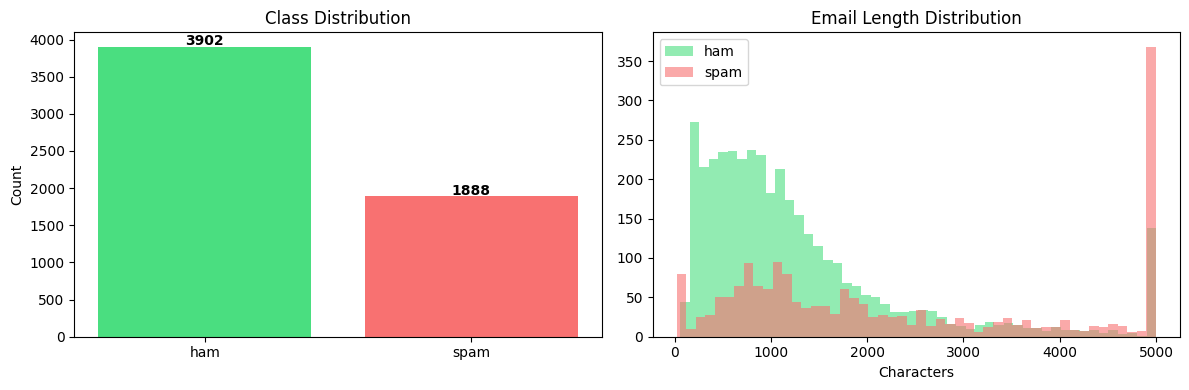

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#4ade80', '#f87171'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Email length distribution
df['length'] = df['text'].str.len()
for label, color in [('ham', '#4ade80'), ('spam', '#f87171')]:
    subset = df[df['label'] == label]['length'].clip(0, 5000)
    axes[1].hist(subset, bins=50, alpha=0.6, label=label, color=color)
axes[1].set_title('Email Length Distribution')
axes[1].set_xlabel('Characters')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Preprocess & split

In [4]:
import re
from sklearn.model_selection import train_test_split

def clean(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' URL ', text)  # replace URLs
    text = re.sub(r'\S+@\S+', ' EMAIL ', text)          # replace emails
    text = re.sub(r'\d+', ' NUM ', text)                 # replace numbers
    text = re.sub(r'[^\w\s]', ' ', text)                 # strip punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean'] = df['text'].apply(clean)

X_train, X_test, y_train, y_test = train_test_split(
    df['clean'], df['label_num'],
    test_size=0.2, random_state=42, stratify=df['label_num']
)

print(f'Train: {len(X_train)}  Test: {len(X_test)}')

Train: 4632  Test: 1158


## 6. Vectorize with TF-IDF

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),   # unigrams + bigrams
    min_df=2,
    sublinear_tf=True,
    stop_words='english'
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

print(f'Vocabulary size: {len(vectorizer.vocabulary_)}')
print(f'Matrix shape: {X_train_vec.shape}')

Vocabulary size: 30000
Matrix shape: (4632, 30000)


## 7. Train & compare models

In [6]:
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
import time

models = {
    'Multinomial NB':  MultinomialNB(alpha=0.1),
    'Complement NB':   ComplementNB(alpha=0.1),
    'Logistic Reg':    LogisticRegression(max_iter=1000, C=5, solver='lbfgs'),
    'Linear SVM':      LinearSVC(C=1.0, max_iter=2000),
}

results = {}
for name, clf in models.items():
    t0 = time.time()
    clf.fit(X_train_vec, y_train)
    preds = clf.predict(X_test_vec)
    acc = accuracy_score(y_test, preds)
    elapsed = time.time() - t0
    results[name] = acc
    print(f'{name:20s}  acc={acc:.4f}  ({elapsed:.1f}s)')

best_name = max(results, key=results.get)
print(f'\nBest model: {best_name} ({results[best_name]:.4f})')

Multinomial NB        acc=0.9784  (0.0s)
Complement NB         acc=0.9853  (0.0s)
Logistic Reg          acc=0.9853  (1.7s)
Linear SVM            acc=0.9896  (0.0s)

Best model: Linear SVM (0.9896)


## 8. Full evaluation of best model

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       780
        spam       1.00      0.97      0.98       378

    accuracy                           0.99      1158
   macro avg       0.99      0.98      0.99      1158
weighted avg       0.99      0.99      0.99      1158



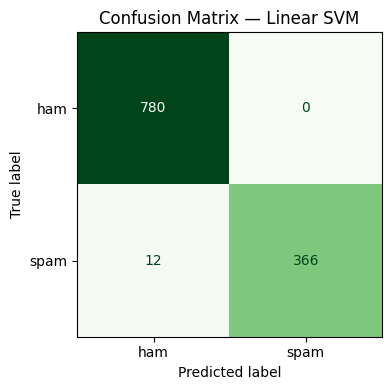

In [7]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_clf = models[best_name]
preds = best_clf.predict(X_test_vec)

print(classification_report(y_test, preds, target_names=['ham', 'spam']))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['ham', 'spam'])
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()

## 9. Top predictive features

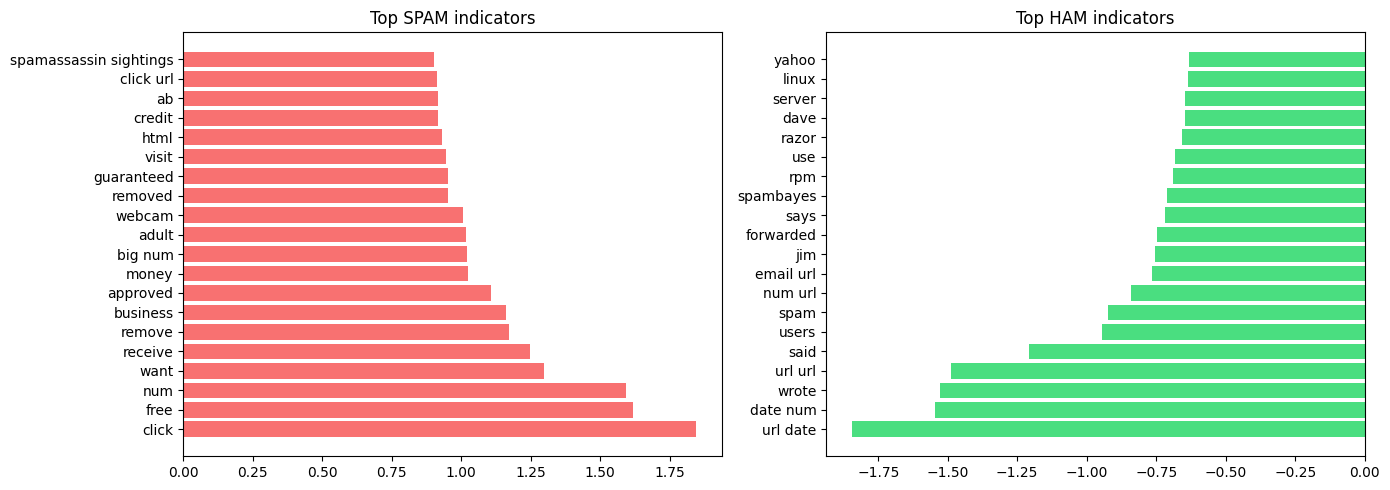

In [8]:
# Works well for Logistic Regression and Naive Bayes
import numpy as np

feature_names = vectorizer.get_feature_names_out()

if hasattr(best_clf, 'coef_'):
    coefs = best_clf.coef_.ravel() if best_clf.coef_.ndim > 1 else best_clf.coef_
    top_spam = np.argsort(coefs)[-20:][::-1]
    top_ham  = np.argsort(coefs)[:20]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].barh([feature_names[i] for i in top_spam], coefs[top_spam], color='#f87171')
    axes[0].set_title('Top SPAM indicators')
    axes[1].barh([feature_names[i] for i in top_ham],  coefs[top_ham],  color='#4ade80')
    axes[1].set_title('Top HAM indicators')
    plt.tight_layout()
    plt.show()
elif hasattr(best_clf, 'feature_log_prob_'):
    log_prob_diff = best_clf.feature_log_prob_[1] - best_clf.feature_log_prob_[0]
    top_spam = np.argsort(log_prob_diff)[-20:][::-1]
    top_ham  = np.argsort(log_prob_diff)[:20]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].barh([feature_names[i] for i in top_spam], log_prob_diff[top_spam], color='#f87171')
    axes[0].set_title('Top SPAM indicators')
    axes[1].barh([feature_names[i] for i in top_ham],  log_prob_diff[top_ham],  color='#4ade80')
    axes[1].set_title('Top HAM indicators')
    plt.tight_layout()
    plt.show()
else:
    print('Feature importance not available for this model type.')

## 10. Export model & vectorizer

In [9]:
import joblib

joblib.dump(best_clf,   'model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')

print('Saved model.pkl and vectorizer.pkl')
print('Copy both files to the api/ folder next to app.py')

Saved model.pkl and vectorizer.pkl
Copy both files to the api/ folder next to app.py


## 11. Quick sanity check

In [10]:
TEST_EMAILS = [
    ('WINNER! You have been selected for a $1,000,000 prize. Click here now to claim FREE!!!', 'spam'),
    ('Hi team, please find attached the Q3 report. Let me know if you have questions.', 'ham'),
    ('URGENT: Your account has been compromised. Verify your details immediately at our website.', 'spam'),
    ('Can we move the 3pm meeting to 4pm? I have a conflict.', 'ham'),
]

print(f'{'Text':60s}  Expected  Predicted')
print('-' * 85)
for text, expected in TEST_EMAILS:
    cleaned = clean(text)
    vec = vectorizer.transform([cleaned])
    pred_num = best_clf.predict(vec)[0]
    predicted = 'spam' if pred_num == 1 else 'ham'
    ok = '✓' if predicted == expected else '✗'
    print(f'{text[:58]:60s}  {expected:8s}  {predicted}  {ok}')

Text                                                          Expected  Predicted
-------------------------------------------------------------------------------------
WINNER! You have been selected for a $1,000,000 prize. Cli    spam      spam  ✓
Hi team, please find attached the Q3 report. Let me know i    ham       spam  ✗
URGENT: Your account has been compromised. Verify your det    spam      spam  ✓
Can we move the 3pm meeting to 4pm? I have a conflict.        ham       ham  ✓
